# Credit Card Default Risk Prediction — End-to-End MLOps Project

**Dataset:** UCI Credit Card Default dataset  
**Target:** `default.payment.next.month` (`1 = default`, `0 = no default`)  
**Deployment:** Streamlit on Hugging Face Spaces  
**Automation:** GitHub Actions  
**Experiment tracking:** MLflow

This notebook follows the final-project requirement and the class reference architecture:

`Dataset registration → Data preparation → Model training/evaluation → Model registration → Streamlit application → Hugging Face deployment → GitHub Actions automation`

The code is intentionally simple, commented and modular. The priority is a complete, reproducible pipeline rather than unnecessary complexity.

## 1. Business problem and responsible-AI scope

A bank wants an early-warning tool that estimates the probability that a credit-card customer will default in the next month. The application is intended to support risk review and prioritisation—not to make an automatic lending decision.

### Predictor policy

The model uses financial and repayment-behaviour variables. The following columns are excluded from model training:

- `ID`: identifier only.
- `SEX`, `EDUCATION`, `MARRIAGE`: retained for EDA/fairness analysis but excluded from prediction.
- `default.payment.next.month`: target variable.

`AGE` is retained as an agreed predictor. All columns, including excluded demographic variables, remain available for descriptive analysis.

### Repayment-status interpretation

For `PAY_0`, `PAY_2`, ..., `PAY_6`:

- `-2 = no consumption`
- `-1 = paid duly`
- `0 = revolving credit use`
- `1–9 = payment delay in months` (`9 = nine months or above`)

## 2. Setup

Upload `UCI_Credit_Card.csv` into the notebook working directory before running. In Colab, the provided helper will also look under `/content` and `/mnt/data`.

In [ ]:
# Install only when needed (uncomment in a fresh Colab runtime)
# !pip install -q pandas numpy matplotlib scikit-learn xgboost joblib mlflow huggingface_hub streamlit

In [2]:
from pathlib import Path
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
TARGET = 'default.payment.next.month'

## 3. Load and inspect the dataset

In [4]:
def find_dataset():
    candidates = [
        Path('UCI_Credit_Card.csv'),
        Path('UCI_Credit_Card(1).csv'),
        Path('/content/UCI_Credit_Card.csv'),
        Path('/content/UCI_Credit_Card(1).csv'),
        Path('/mnt/data/UCI_Credit_Card.csv'),
        Path('/mnt/data/UCI_Credit_Card(1).csv'),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError('Upload UCI_Credit_Card.csv and rerun this cell.')

DATA_PATH = find_dataset()
df = pd.read_csv(DATA_PATH)
print('Dataset path:', DATA_PATH)
print('Shape:', df.shape)
df.head()

Dataset path: UCI_Credit_Card.csv
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print('Data types:')
display(df.dtypes.to_frame('dtype'))

print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate IDs:', int(df['ID'].duplicated().sum()))

Data types:


,dtype
ID,int64
LIMIT_BAL,float64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


Missing values: 0
Duplicate rows: 0
Duplicate IDs: 0


## 4. Data-quality checks and EDA

EDA includes all features. Demographic columns are analysed but are not supplied to the final model.

In [4]:
# Validate the expected schema early so that pipeline failures are easy to understand.
EXPECTED_COLUMNS = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    TARGET
]
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
assert not missing_columns, f'Missing columns: {missing_columns}'
print('Schema check passed.')

Schema check passed.


,count,percentage
No default (0),23364,77.88
Default (1),6636,22.12


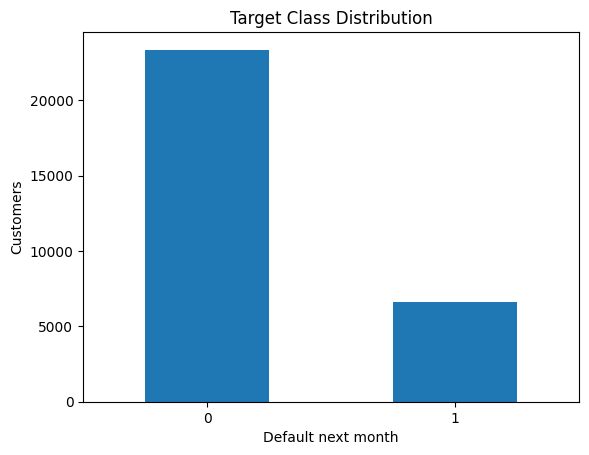

In [5]:
# Target balance
class_counts = df[TARGET].value_counts().sort_index()
class_pct = (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2)
target_summary = pd.DataFrame({'count': class_counts, 'percentage': class_pct})
target_summary.index = ['No default (0)', 'Default (1)']
display(target_summary)

ax = class_counts.plot(kind='bar', title='Target Class Distribution')
ax.set_xlabel('Default next month')
ax.set_ylabel('Customers')
plt.xticks(rotation=0)
plt.show()

In [6]:
# Review categorical codes, including values that require documentation.
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f'\n{col}')
    display(df[col].value_counts(dropna=False).sort_index().to_frame('count'))

pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in pay_status_cols:
    print(f'\n{col}:', sorted(df[col].unique().tolist()))


SEX


,count
SEX,
1,11888
2,18112



EDUCATION


,count
EDUCATION,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51



MARRIAGE


,count
MARRIAGE,
0,54
1,13659
2,15964
3,323



PAY_0: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_2: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_3: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_4: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_5: [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

PAY_6: [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


In [7]:
# Human-readable EDA labels. These mappings are for analysis only.
eda_df = df.copy()
eda_df['SEX_LABEL'] = eda_df['SEX'].map({1: 'Male', 2: 'Female'}).fillna('Unknown')
eda_df['EDUCATION_LABEL'] = eda_df['EDUCATION'].replace({
    0: 'Other/Unknown', 1: 'Graduate school', 2: 'University',
    3: 'High school', 4: 'Other/Unknown', 5: 'Other/Unknown', 6: 'Other/Unknown'
})
eda_df['MARRIAGE_LABEL'] = eda_df['MARRIAGE'].replace({
    0: 'Other/Unknown', 1: 'Married', 2: 'Single', 3: 'Other/Unknown'
})
eda_df['AGE_GROUP'] = pd.cut(
    eda_df['AGE'], bins=[0, 29, 39, 49, 59, np.inf],
    labels=['Under 30', '30–39', '40–49', '50–59', '60+']
)

for col in ['SEX_LABEL', 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP']:
    summary = eda_df.groupby(col, observed=False)[TARGET].agg(['count', 'mean'])
    summary['default_rate_pct'] = (summary['mean'] * 100).round(2)
    print(f'\nDefault rate by {col}')
    display(summary[['count', 'default_rate_pct']])


Default rate by SEX_LABEL


,count,default_rate_pct
SEX_LABEL,,
Female,18112,20.78
Male,11888,24.17



Default rate by EDUCATION_LABEL


,count,default_rate_pct
EDUCATION_LABEL,,
Graduate school,10585,19.23
High school,4917,25.16
Other/Unknown,468,7.05
University,14030,23.73



Default rate by MARRIAGE_LABEL


,count,default_rate_pct
MARRIAGE_LABEL,,
Married,13659,23.47
Other/Unknown,377,23.61
Single,15964,20.93



Default rate by AGE_GROUP


,count,default_rate_pct
AGE_GROUP,,
Under 30,9618,22.84
30–39,11238,20.25
40–49,6464,22.97
50–59,2341,24.86
60+,339,28.32


,count,default_rate_pct
PAY_0,,
-2,2759,13.23
-1,5686,16.78
0,14737,12.81
1,3688,33.95
2,2667,69.14
3,322,75.78
4,76,68.42
5,26,50.00
6,11,54.55


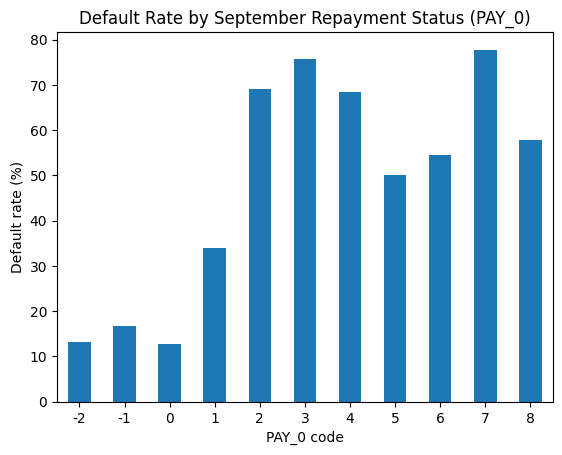

In [8]:
# Repayment status is expected to be strongly related to default.
pay0_summary = df.groupby('PAY_0')[TARGET].agg(['count', 'mean'])
pay0_summary['default_rate_pct'] = (pay0_summary['mean'] * 100).round(2)
display(pay0_summary[['count', 'default_rate_pct']])

ax = pay0_summary['default_rate_pct'].plot(kind='bar', title='Default Rate by September Repayment Status (PAY_0)')
ax.set_xlabel('PAY_0 code')
ax.set_ylabel('Default rate (%)')
plt.xticks(rotation=0)
plt.show()

In [9]:
# Summary of numerical values and potential outliers.
financial_cols = ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]
display(df[financial_cols].describe().T)

# Correlation with target is descriptive; it is not used alone to select features.
corr = df.drop(columns=['ID']).corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
display(corr.to_frame('correlation_with_target'))

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0


,correlation_with_target
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
LIMIT_BAL,-0.153520
PAY_AMT1,-0.072929
PAY_AMT2,-0.058579
PAY_AMT4,-0.056827


## 5. Feature engineering

The same function is reused in training and deployment to prevent training-serving mismatch.

Created features:

- `AVERAGE_BILL`
- `LATEST_UTILISATION`
- `AVERAGE_UTILISATION`
- `UTILISATION_1` to `UTILISATION_6`

Utilisation is bill amount divided by credit limit. The denominator is protected against zero values, although this dataset normally has positive limits.

In [10]:
MODEL_EXCLUDED = ['ID', 'SEX', 'EDUCATION', 'MARRIAGE', TARGET]
RAW_MODEL_FEATURES = [c for c in df.columns if c not in MODEL_EXCLUDED]
BILL_COLS = [f'BILL_AMT{i}' for i in range(1, 7)]
PAYMENT_COLS = [f'PAY_AMT{i}' for i in range(1, 7)]
STATUS_COLS = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create model features from raw customer records."""
    output = data.copy()

    # Avoid division by zero while preserving valid rows.
    safe_limit = output['LIMIT_BAL'].replace(0, np.nan)

    output['AVERAGE_BILL'] = output[BILL_COLS].mean(axis=1)
    output['LATEST_UTILISATION'] = output['BILL_AMT1'] / safe_limit
    output['AVERAGE_UTILISATION'] = output['AVERAGE_BILL'] / safe_limit

    for month in range(1, 7):
        output[f'UTILISATION_{month}'] = output[f'BILL_AMT{month}'] / safe_limit

    # Replace only division-generated infinity/NaN with zero.
    output = output.replace([np.inf, -np.inf], np.nan)
    output = output.fillna(0)
    return output

X_raw = df[RAW_MODEL_FEATURES].copy()
y = df[TARGET].copy()
X = engineer_features(X_raw)

print('Raw model features:', len(RAW_MODEL_FEATURES))
print('Features after engineering:', X.shape[1])
display(X.head())

Raw model features: 20
Features after engineering: 29


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,AVERAGE_BILL,LATEST_UTILISATION,AVERAGE_UTILISATION,UTILISATION_1,UTILISATION_2,UTILISATION_3,UTILISATION_4,UTILISATION_5,UTILISATION_6
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1284.000000,0.195650,0.064200,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,2846.166667,0.022350,0.023718,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,16942.166667,0.324878,0.188246,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,38555.666667,0.939800,0.771113,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,18223.166667,0.172340,0.364463,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620


## 6. Stratified train, validation and test split

- Training data fits the models.
- Validation data selects the best model and probability threshold.
- Test data is used once for final unbiased evaluation.

In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y_train_val
)

split_summary = pd.DataFrame({
    'rows': [len(X_train), len(X_val), len(X_test)],
    'default_rate': [y_train.mean(), y_val.mean(), y_test.mean()]
}, index=['Train', 'Validation', 'Test'])
display(split_summary)

,rows,default_rate
Train,18000,0.221222
Validation,6000,0.221167
Test,6000,0.221167


## 7. Model training and class-imbalance handling

Two understandable models are compared:

1. **Logistic Regression** — interpretable baseline, with balanced class weights and robust scaling.
2. **Random Forest** — captures non-linear behaviour, with balanced class weights.

This avoids the very large grid search in the practice notebook. The final objective is a stable end-to-end pipeline.

In [12]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', RobustScaler()),
        ('model', LogisticRegression(
            max_iter=1500, class_weight='balanced', random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: Random Forest


## 8. Validation comparison and threshold selection

The model is selected primarily by validation ROC-AUC. The classification threshold is then chosen on validation data to maximise F1 for the default class. Accuracy is reported but is not the principal metric because the target is imbalanced.

In [13]:
def best_f1_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1_values = 2 * precision * recall / (precision + recall + 1e-12)
    best_index = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_index]), float(f1_values[best_index])

validation_rows = []
for name, model in models.items():
    prob = model.predict_proba(X_val)[:, 1]
    threshold, best_f1 = best_f1_threshold(y_val, prob)
    pred = (prob >= threshold).astype(int)
    validation_rows.append({
        'model': name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_val, pred),
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred, zero_division=0),
        'f1': f1_score(y_val, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_val, prob),
        'pr_auc': average_precision_score(y_val, prob)
    })

validation_results = pd.DataFrame(validation_rows).sort_values('roc_auc', ascending=False)
display(validation_results)

best_model_name = validation_results.iloc[0]['model']
best_threshold = float(validation_results.iloc[0]['threshold'])
best_model = models[best_model_name]
print('Selected model:', best_model_name)
print('Selected threshold:', round(best_threshold, 4))

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.502287,0.797833,0.542857,0.544084,0.543470,0.781616,0.543794
0,Logistic Regression,0.559036,0.780500,0.503602,0.526752,0.514917,0.718813,0.487247


Selected model: Random Forest
Selected threshold: 0.5023


## 9. Final test evaluation

In [14]:
test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

final_metrics = {
    'accuracy': accuracy_score(y_test, test_pred),
    'precision': precision_score(y_test, test_pred, zero_division=0),
    'recall': recall_score(y_test, test_pred, zero_division=0),
    'f1': f1_score(y_test, test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, test_prob),
    'pr_auc': average_precision_score(y_test, test_prob)
}

display(pd.DataFrame([final_metrics], index=[best_model_name]).round(4))
print(classification_report(y_test, test_pred, target_names=['No default', 'Default']))
print('Confusion matrix:')
display(pd.DataFrame(
    confusion_matrix(y_test, test_pred),
    index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']
))

,accuracy,precision,recall,f1,roc_auc,pr_auc
Random Forest,0.7943,0.5348,0.5388,0.5368,0.7755,0.5511


              precision    recall  f1-score   support

  No default       0.87      0.87      0.87      4673
     Default       0.53      0.54      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.79      0.79      0.79      6000

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,4051,622
Actual 1,612,715


## 10. Fairness-oriented evaluation

Sensitive variables were not used by the model. They are now joined back only to inspect whether error rates differ between groups. This is an audit, not proof that the model is legally or ethically fair.

In [15]:
# Recover the original demographic rows using test indices.
audit = df.loc[X_test.index, ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', TARGET]].copy()
audit['prediction'] = test_pred
audit['probability'] = test_prob

audit['SEX_LABEL'] = audit['SEX'].map({1: 'Male', 2: 'Female'}).fillna('Unknown')
audit['AGE_GROUP'] = pd.cut(
    audit['AGE'], bins=[0, 29, 39, 49, 59, np.inf],
    labels=['Under 30', '30–39', '40–49', '50–59', '60+']
)

def group_audit(data, group_col):
    rows = []
    for group, part in data.groupby(group_col, observed=False):
        rows.append({
            group_col: group,
            'customers': len(part),
            'actual_default_rate': part[TARGET].mean(),
            'predicted_positive_rate': part['prediction'].mean(),
            'recall': recall_score(part[TARGET], part['prediction'], zero_division=0),
            'precision': precision_score(part[TARGET], part['prediction'], zero_division=0)
        })
    return pd.DataFrame(rows)

display(group_audit(audit, 'SEX_LABEL'))
display(group_audit(audit, 'AGE_GROUP'))

,SEX_LABEL,customers,actual_default_rate,predicted_positive_rate,recall,precision
0,Female,3598,0.212896,0.211228,0.543081,0.547368
1,Male,2402,0.233555,0.240216,0.532977,0.518198


,AGE_GROUP,customers,actual_default_rate,predicted_positive_rate,recall,precision
0,Under 30,1912,0.223326,0.245293,0.566745,0.515991
1,30–39,2198,0.206096,0.197907,0.518764,0.540230
2,40–49,1341,0.232662,0.220731,0.525641,0.554054
3,50–59,473,0.236786,0.247357,0.562500,0.538462
4,60+,76,0.302632,0.263158,0.478261,0.550000


## 11. Save the final model, metadata and MLflow experiment

MLflow is used properly here to log parameters, validation/test metrics and model artefacts. A local file-based tracking store is sufficient for the academic pipeline; the generated GitHub workflow also uploads the run artefacts to the Hugging Face model repository.

In [16]:
ARTIFACT_DIR = Path('mlops/artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACT_DIR / 'credit_default_model.joblib'
metadata_path = ARTIFACT_DIR / 'model_metadata.json'

joblib.dump(best_model, model_path)
metadata = {
    'model_name': best_model_name,
    'threshold': best_threshold,
    'raw_model_features': RAW_MODEL_FEATURES,
    'engineered_model_features': X.columns.tolist(),
    'target': TARGET,
    'repayment_status_mapping': {
        '-2': 'no consumption', '-1': 'paid duly', '0': 'revolving credit use',
        '1-9': 'payment delay in months; 9 means nine months or above'
    },
    'test_metrics': final_metrics
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Saved:', model_path)
print('Saved:', metadata_path)

Saved: mlops/artifacts/credit_default_model.joblib
Saved: mlops/artifacts/model_metadata.json


In [19]:
import importlib, subprocess, sys

# MLflow logging. This cell can be rerun safely.
# Ensure mlflow is available in this runtime; install if missing.
try:
    mlflow = importlib.import_module("mlflow")
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlflow"])
    mlflow = importlib.import_module("mlflow")
import mlflow.sklearn

mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('credit-card-default-risk')

with mlflow.start_run(run_name=best_model_name):
    mlflow.log_param('selected_model', best_model_name)
    mlflow.log_param('threshold', best_threshold)
    mlflow.log_param('train_rows', len(X_train))
    mlflow.log_param('validation_rows', len(X_val))
    mlflow.log_param('test_rows', len(X_test))
    mlflow.log_metrics({f'test_{k}': float(v) for k, v in final_metrics.items()})
    mlflow.log_artifact(str(metadata_path))
    mlflow.sklearn.log_model(best_model, artifact_path='model')

print('MLflow run logged under ./mlruns')

Defaulting to user installation because normal site-packages is not writeable
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.16.5-py3-none-any.whl.metadata (7.3 kB)
  Using cached docker-7.2.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached sqlalchemy-2.0.51-cp39-cp39-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached fastapi-0.128.8-py3-none-any.whl.metadata (30 kB)
  Using cached gitpython-3.1.57-py3-none-any.whl.metadata (13 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pyyaml-6.0.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached uvicorn-0.39.0-py3-none-any.wh

2026/07/28 18:16:43 INFO mlflow.tracking.fluent: Experiment with name 'credit-card-default-risk' does not exist. Creating a new experiment.
2026/07/28 18:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/28 18:16:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run logged under ./mlruns


# 12. Generate the complete MLOps project files

The following cells create a clean repository structure matching the class reference while addressing its concerns:

- Explicit Python setup in GitHub Actions.
- `actions/checkout@v4`.
- Stratified train/validation/test split.
- Two-model comparison instead of one model.
- Real MLflow logging.
- No unused MLflow server.
- Small, fixed model configurations instead of thousands of grid-search fits.
- Threshold saved in metadata rather than hard-coded in the app.
- Single and batch prediction tabs.
- Probability display and downloadable scored CSV.
- Schema validation and basic error handling.

In [5]:
PROJECT_ROOT = Path('mlops')
for folder in [
    PROJECT_ROOT / 'data',
    PROJECT_ROOT / 'model_building',
    PROJECT_ROOT / 'deployment',
    PROJECT_ROOT / 'hosting',
    Path('.github/workflows')
]:
    folder.mkdir(parents=True, exist_ok=True)

# Copy local dataset into the project data folder.
project_data_path = PROJECT_ROOT / 'data' / 'UCI_Credit_Card.csv'
pd.read_csv(DATA_PATH).to_csv(project_data_path, index=False)
print('Project folders created.')

Project folders created.


## 12.1 Shared feature utility

In [6]:
%%writefile mlops/feature_utils.py
import numpy as np
import pandas as pd

TARGET = "default.payment.next.month"
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
STATUS_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
PAYMENT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
EXCLUDED_FROM_MODEL = ["ID", "SEX", "EDUCATION", "MARRIAGE", TARGET]

RAW_MODEL_FEATURES = [
    "LIMIT_BAL", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]


def validate_raw_features(data: pd.DataFrame) -> None:
    missing = sorted(set(RAW_MODEL_FEATURES) - set(data.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create the exact features used during training and prediction."""
    validate_raw_features(data)
    output = data[RAW_MODEL_FEATURES].copy()
    safe_limit = output["LIMIT_BAL"].replace(0, np.nan)

    output["AVERAGE_BILL"] = output[BILL_COLS].mean(axis=1)
    output["LATEST_UTILISATION"] = output["BILL_AMT1"] / safe_limit
    output["AVERAGE_UTILISATION"] = output["AVERAGE_BILL"] / safe_limit

    for month in range(1, 7):
        output[f"UTILISATION_{month}"] = output[f"BILL_AMT{month}"] / safe_limit

    return output.replace([np.inf, -np.inf], np.nan).fillna(0)

Writing mlops/feature_utils.py


## 12.2 Dataset registration script

In [7]:
%%writefile mlops/model_building/data_register.py
import os
from huggingface_hub import HfApi, create_repo

HF_USERNAME = os.environ["HF_USERNAME"]
DATASET_REPO = f"{HF_USERNAME}/uci-credit-card-default"
DATA_PATH = "mlops/data/UCI_Credit_Card.csv"

api = HfApi(token=os.environ["HF_TOKEN"])
create_repo(DATASET_REPO, repo_type="dataset", exist_ok=True, token=os.environ["HF_TOKEN"])
api.upload_file(
    path_or_fileobj=DATA_PATH,
    path_in_repo="UCI_Credit_Card.csv",
    repo_id=DATASET_REPO,
    repo_type="dataset"
)
print(f"Dataset uploaded to {DATASET_REPO}")

Writing mlops/model_building/data_register.py


## 12.3 Data-preparation script

In [8]:
%%writefile mlops/model_building/prep.py
import os
from pathlib import Path
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download
from sklearn.model_selection import train_test_split

TARGET = "default.payment.next.month"
RANDOM_STATE = 42
HF_USERNAME = os.environ["HF_USERNAME"]
DATASET_REPO = f"{HF_USERNAME}/uci-credit-card-default"

api = HfApi(token=os.environ["HF_TOKEN"])
raw_path = hf_hub_download(
    repo_id=DATASET_REPO,
    filename="UCI_Credit_Card.csv",
    repo_type="dataset",
    token=os.environ["HF_TOKEN"]
)
df = pd.read_csv(raw_path)

required = {"ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", TARGET}
if not required.issubset(df.columns):
    raise ValueError(f"Dataset schema is incomplete: {sorted(required - set(df.columns))}")

# Keep all columns in split files so demographics remain available for EDA/auditing.
train_val, test = train_test_split(
    df, test_size=0.20, random_state=RANDOM_STATE, stratify=df[TARGET]
)
train, validation = train_test_split(
    train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=train_val[TARGET]
)

output_dir = Path("mlops/data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
for name, part in {"train": train, "validation": validation, "test": test}.items():
    path = output_dir / f"{name}.csv"
    part.to_csv(path, index=False)
    api.upload_file(
        path_or_fileobj=str(path), path_in_repo=f"processed/{name}.csv",
        repo_id=DATASET_REPO, repo_type="dataset"
    )
    print(name, part.shape, "default rate:", round(part[TARGET].mean(), 4))

Writing mlops/model_building/prep.py


## 12.4 Model-training, evaluation, MLflow and model registration script

In [ ]:
%%writefile mlops/model_building/train.py
import json
import os
import sys
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
from huggingface_hub import HfApi, create_repo, hf_hub_download
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

sys.path.append("mlops")
from feature_utils import TARGET, RAW_MODEL_FEATURES, engineer_features

RANDOM_STATE = 42
HF_USERNAME = os.environ["HF_USERNAME"]
DATASET_REPO = f"{HF_USERNAME}/uci-credit-card-default"
MODEL_REPO = f"{HF_USERNAME}/credit-card-default-model"
TOKEN = os.environ["HF_TOKEN"]


def load_split(name):
    path = hf_hub_download(
        repo_id=DATASET_REPO, filename=f"processed/{name}.csv",
        repo_type="dataset", token=TOKEN
    )
    frame = pd.read_csv(path)
    return engineer_features(frame[RAW_MODEL_FEATURES]), frame[TARGET]


def best_f1_threshold(y_true, probability):
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    idx = int(f1[:-1].argmax())
    return float(thresholds[idx])


def metrics(y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }

X_train, y_train = load_split("train")
X_val, y_val = load_split("validation")
X_test, y_test = load_split("test")

models = {
    "Logistic Regression": Pipeline([
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=12, min_samples_leaf=5,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
    )
}

validation_results = []
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_val)[:, 1]
    threshold = best_f1_threshold(y_val, probability)
    row = {"model": name, "threshold": threshold, **metrics(y_val, probability, threshold)}
    validation_results.append(row)
    trained[name] = model

validation_df = pd.DataFrame(validation_results).sort_values("roc_auc", ascending=False)
best_name = validation_df.iloc[0]["model"]
best_threshold = float(validation_df.iloc[0]["threshold"])
best_model = trained[best_name]

test_probability = best_model.predict_proba(X_test)[:, 1]
test_metrics = metrics(y_test, test_probability, best_threshold)

artifact_dir = Path("mlops/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)
model_path = artifact_dir / "credit_default_model.joblib"
metadata_path = artifact_dir / "model_metadata.json"
comparison_path = artifact_dir / "validation_comparison.csv"

joblib.dump(best_model, model_path)
validation_df.to_csv(comparison_path, index=False)
metadata = {
    "model_name": best_name,
    "threshold": best_threshold,
    "raw_model_features": RAW_MODEL_FEATURES,
    "engineered_features": X_train.columns.tolist(),
    "test_metrics": test_metrics
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

# Real experiment logging. A file store works in GitHub Actions and is uploaded as an artefact.
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("credit-card-default-risk")
with mlflow.start_run(run_name=best_name):
    mlflow.log_param("selected_model", best_name)
    mlflow.log_param("threshold", best_threshold)
    mlflow.log_metrics({f"test_{k}": float(v) for k, v in test_metrics.items()})
    mlflow.log_artifact(str(metadata_path))
    mlflow.log_artifact(str(comparison_path))
    mlflow.sklearn.log_model(best_model, artifact_path="model")

api = HfApi(token=TOKEN)
create_repo(MODEL_REPO, repo_type="model", exist_ok=True, token=TOKEN)
for path in [model_path, metadata_path, comparison_path]:
    api.upload_file(
        path_or_fileobj=str(path), path_in_repo=path.name,
        repo_id=MODEL_REPO, repo_type="model"
    )
print("Selected model:", best_name)
print("Threshold:", round(best_threshold, 4))
print("Test metrics:", test_metrics)

Writing mlops/model_building/train.py


## 12.5 Streamlit application with overview, single and batch tabs

In [ ]:
%%writefile mlops/deployment/app.py
import io
import json
import os
import sys

import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

sys.path.append(os.path.dirname(__file__))
from feature_utils import RAW_MODEL_FEATURES, engineer_features, validate_raw_features

st.set_page_config(page_title="Credit Card Default Risk", layout="wide")
HF_USERNAME = os.getenv("HF_USERNAME")
MODEL_REPO = f"{HF_USERNAME}/credit-card-default-model"

@st.cache_resource
def load_assets():
    model_path = hf_hub_download(MODEL_REPO, "credit_default_model.joblib")
    metadata_path = hf_hub_download(MODEL_REPO, "model_metadata.json")
    return joblib.load(model_path), json.load(open(metadata_path, encoding="utf-8"))

try:
    model, metadata = load_assets()
except Exception as exc:
    st.error(f"Model could not be loaded. Check HF_USERNAME and repository access. Details: {exc}")
    st.stop()

threshold = float(metadata["threshold"])
status_options = {
    "No consumption (-2)": -2,
    "Paid duly (-1)": -1,
    "Revolving credit use (0)": 0,
    "1 month delay": 1,
    "2 months delay": 2,
    "3 months delay": 3,
    "4 months delay": 4,
    "5 months delay": 5,
    "6 months delay": 6,
    "7 months delay": 7,
    "8 months delay": 8,
    "9+ months delay": 9,
}
months = [
    ("September 2005", "PAY_0", "BILL_AMT1", "PAY_AMT1"),
    ("August 2005", "PAY_2", "BILL_AMT2", "PAY_AMT2"),
    ("July 2005", "PAY_3", "BILL_AMT3", "PAY_AMT3"),
    ("June 2005", "PAY_4", "BILL_AMT4", "PAY_AMT4"),
    ("May 2005", "PAY_5", "BILL_AMT5", "PAY_AMT5"),
    ("April 2005", "PAY_6", "BILL_AMT6", "PAY_AMT6"),
]

st.title("Credit Card Default Risk Prediction")
st.caption("Decision-support demonstration. The model excludes ID, gender, education and marital status from prediction.")

overview_tab, single_tab, batch_tab = st.tabs(["Overview", "Single Customer", "Batch Upload"])

with overview_tab:
    st.subheader("Application overview")
    st.write("The model estimates next-month default probability using credit limit, age, six-month repayment status, bill history and payment history.")
    c1, c2, c3 = st.columns(3)
    c1.metric("Selected model", metadata["model_name"])
    c2.metric("Decision threshold", f"{threshold:.2f}")
    c3.metric("Model inputs", len(RAW_MODEL_FEATURES))
    st.info("Risk bands are communication aids: Low < 30%, Medium 30–60%, High > 60%. They are not official banking policy thresholds.")

with single_tab:
    st.subheader("Single-customer assessment")
    with st.form("single_customer_form"):
        c1, c2 = st.columns(2)
        limit_bal = c1.number_input("Credit limit (NT$)", min_value=1.0, value=200000.0, step=10000.0)
        age = c2.number_input("Age", min_value=18, max_value=100, value=35)

        st.markdown("#### Six-month repayment status")
        statuses = {}
        status_cols = st.columns(3)
        for i, (month, pay_col, _, _) in enumerate(months):
            label = status_cols[i % 3].selectbox(month, list(status_options), index=2, key=f"status_{pay_col}")
            statuses[pay_col] = status_options[label]

        st.markdown("#### Six-month bill history (NT$)")
        bills = {}
        bill_cols = st.columns(3)
        for i, (month, _, bill_col, _) in enumerate(months):
            bills[bill_col] = bill_cols[i % 3].number_input(month, value=50000.0, step=1000.0, key=f"bill_{bill_col}")

        st.markdown("#### Six-month payment history (NT$)")
        payments = {}
        payment_cols = st.columns(3)
        for i, (month, _, _, payment_col) in enumerate(months):
            payments[payment_col] = payment_cols[i % 3].number_input(month, min_value=0.0, value=5000.0, step=500.0, key=f"payment_{payment_col}")

        submitted = st.form_submit_button("Estimate default risk")

    if submitted:
        record = {"LIMIT_BAL": limit_bal, "AGE": age, **statuses, **bills, **payments}
        raw = pd.DataFrame([record])
        probability = float(model.predict_proba(engineer_features(raw))[:, 1][0])
        prediction = int(probability >= threshold)
        risk = "Low" if probability < 0.30 else "Medium" if probability <= 0.60 else "High"
        st.metric("Default probability", f"{probability:.1%}")
        st.write(f"**Risk band:** {risk}")
        if prediction:
            st.warning("Model result: Flag for additional credit-risk review.")
        else:
            st.success("Model result: Not flagged at the selected threshold.")

with batch_tab:
    st.subheader("Batch scoring")
    st.write("Upload a CSV containing the required raw model columns. Extra columns such as ID may be included and will be preserved in the output.")
    template = pd.DataFrame(columns=RAW_MODEL_FEATURES)
    st.download_button("Download input template", template.to_csv(index=False), "batch_input_template.csv", "text/csv")
    uploaded = st.file_uploader("Upload customer CSV", type="csv")

    if uploaded is not None:
        try:
            batch = pd.read_csv(uploaded)
            validate_raw_features(batch)
            probabilities = model.predict_proba(engineer_features(batch))[:, 1]
            scored = batch.copy()
            scored["default_probability"] = probabilities
            scored["predicted_default"] = (probabilities >= threshold).astype(int)
            scored["risk_band"] = pd.cut(
                probabilities, bins=[-0.001, 0.30, 0.60, 1.0],
                labels=["Low", "Medium", "High"]
            ).astype(str)
            st.success(f"Scored {len(scored):,} customers.")
            st.dataframe(scored.head(50), use_container_width=True)
            st.download_button(
                "Download scored file", scored.to_csv(index=False),
                "credit_default_scored.csv", "text/csv"
            )
        except Exception as exc:
            st.error(f"Batch scoring failed: {exc}")

Writing mlops/deployment/app.py


## 12.6 Deployment support files

In [11]:
%%writefile mlops/deployment/feature_utils.py
import numpy as np
import pandas as pd

TARGET = "default.payment.next.month"
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
RAW_MODEL_FEATURES = [
    "LIMIT_BAL", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

def validate_raw_features(data):
    missing = sorted(set(RAW_MODEL_FEATURES) - set(data.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

def engineer_features(data):
    validate_raw_features(data)
    output = data[RAW_MODEL_FEATURES].copy()
    safe_limit = output["LIMIT_BAL"].replace(0, np.nan)
    output["AVERAGE_BILL"] = output[BILL_COLS].mean(axis=1)
    output["LATEST_UTILISATION"] = output["BILL_AMT1"] / safe_limit
    output["AVERAGE_UTILISATION"] = output["AVERAGE_BILL"] / safe_limit
    for month in range(1, 7):
        output[f"UTILISATION_{month}"] = output[f"BILL_AMT{month}"] / safe_limit
    return output.replace([np.inf, -np.inf], np.nan).fillna(0)

Writing mlops/deployment/feature_utils.py


In [12]:
%%writefile mlops/deployment/requirements.txt
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
streamlit==1.44.1
joblib==1.4.2
huggingface_hub==0.30.2

Writing mlops/deployment/requirements.txt


In [13]:
%%writefile mlops/deployment/README.md
---
title: Credit Card Default Risk
emoji: 💳
colorFrom: blue
colorTo: indigo
sdk: streamlit
sdk_version: 1.44.1
app_file: app.py
pinned: false
---

# Credit Card Default Risk

Streamlit decision-support demonstration deployed through GitHub Actions.

Writing mlops/deployment/README.md


In [14]:
%%writefile mlops/deployment/Dockerfile
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=7860"]

Writing mlops/deployment/Dockerfile


## 12.7 Hugging Face Space hosting script

In [15]:
%%writefile mlops/hosting/hosting.py
import os
from huggingface_hub import HfApi, create_repo

HF_USERNAME = os.environ["HF_USERNAME"]
SPACE_REPO = f"{HF_USERNAME}/credit-card-default-app"
TOKEN = os.environ["HF_TOKEN"]

create_repo(
    SPACE_REPO, repo_type="space", space_sdk="streamlit",
    exist_ok=True, token=TOKEN
)
HfApi(token=TOKEN).upload_folder(
    folder_path="mlops/deployment",
    repo_id=SPACE_REPO,
    repo_type="space"
)
print(f"Application deployed to {SPACE_REPO}")

Writing mlops/hosting/hosting.py


## 12.8 Requirements for GitHub Actions

In [16]:
%%writefile mlops/requirements.txt
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
joblib==1.4.2
mlflow==2.21.3
huggingface_hub==0.30.2

Writing mlops/requirements.txt


## 12.9 GitHub Actions workflow

Add these GitHub repository secrets before running:

- `HF_TOKEN`: Hugging Face write token.
- `HF_USERNAME`: Hugging Face username or organisation name.

The workflow follows the reference jobs but adds setup, validation and artefact retention. Retraining still runs on `main` pushes for a clear classroom demonstration.

In [17]:
%%writefile .github/workflows/deploy.yml
name: Credit Default MLOps Pipeline

on:
  push:
    branches: [main]
  workflow_dispatch:

permissions:
  contents: read

jobs:
  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"
          cache: pip
      - run: pip install -r mlops/requirements.txt
      - name: Register dataset on Hugging Face
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python mlops/model_building/data_register.py

  data-preparation:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"
          cache: pip
      - run: pip install -r mlops/requirements.txt
      - name: Create stratified train-validation-test data
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python mlops/model_building/prep.py

  model-training:
    needs: data-preparation
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"
          cache: pip
      - run: pip install -r mlops/requirements.txt
      - name: Train, compare, evaluate and register model
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python mlops/model_building/train.py
      - name: Keep evaluation and MLflow artefacts
        uses: actions/upload-artifact@v4
        with:
          name: model-evaluation-and-mlflow
          path: |
            mlops/artifacts
            mlruns

  deploy-space:
    needs: model-training
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"
          cache: pip
      - run: pip install -r mlops/requirements.txt
      - name: Deploy Streamlit application
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python mlops/hosting/hosting.py

Writing .github/workflows/deploy.yml


## 12.10 Basic smoke tests

In [18]:
%%writefile mlops/smoke_test.py
import sys
import pandas as pd
sys.path.append("mlops")
from feature_utils import RAW_MODEL_FEATURES, engineer_features

sample = pd.DataFrame([{column: 0 for column in RAW_MODEL_FEATURES}])
sample["LIMIT_BAL"] = 100000
sample["AGE"] = 35
result = engineer_features(sample)
assert not result.empty
assert "AVERAGE_BILL" in result.columns
assert "LATEST_UTILISATION" in result.columns
assert "AVERAGE_UTILISATION" in result.columns
print("Smoke test passed.")

Writing mlops/smoke_test.py


# 13. Suggested repository structure

```text
project-root/
├── .github/
│   └── workflows/
│       └── deploy.yml
├── mlops/
│   ├── data/
│   │   └── UCI_Credit_Card.csv
│   ├── model_building/
│   │   ├── data_register.py
│   │   ├── prep.py
│   │   └── train.py
│   ├── deployment/
│   │   ├── app.py
│   │   ├── feature_utils.py
│   │   ├── requirements.txt
│   │   ├── README.md
│   │   └── Dockerfile
│   ├── hosting/
│   │   └── hosting.py
│   ├── feature_utils.py
│   ├── requirements.txt
│   └── smoke_test.py
└── Credit_Card_Default_MLOps_Final_Project.ipynb
```

## Final notes

- Run the analysis/model-development sections locally or in Colab first.
- Replace no code-level username: use `HF_USERNAME` as a GitHub secret.
- Keep `HF_TOKEN` private.
- The final report should include EDA findings, model comparison, threshold rationale, fairness audit, GitHub workflow screenshot, model repository, deployed Space and a visible UI-change redeployment test.